In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Colab \Notebooks/microscopy_self_supervised_learning/

/content/drive/MyDrive/Colab Notebooks/microscopy_self_supervised_learning


imports

In [3]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, silhouette_score
from scipy.spatial.distance import cdist
import os

Load data

In [4]:
RESULTS_DIR = "/results/tables"
os.makedirs(RESULTS_DIR, exist_ok=True)

In [5]:
embeddings = np.load("data/processed/ssl_embeddings.npy")
metadata = pd.read_csv("data/processed/metadata_with_moa.csv")

labels = metadata["moa"].values
le = LabelEncoder()
y = le.fit_transform(labels)

In [ ]:
metadata["moa"].value_counts()

,count
moa,
Microtubule stabilizers,108
DMSO,72
Aurora kinase inhibitors,72
Actin disruptors,24
Microtubule destabilizers,24


kNN classification

In [6]:
from sklearn.preprocessing import normalize
embeddings = normalize(embeddings)

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.2, random_state=42
)

for k in [1,3,5,7, 10,20]:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)

  y_pred = knn.predict(X_test)
  acc = accuracy_score(y_test, y_pred)

  print("kNN Accuracy:", acc, "k is", k)

ValueError: Found input variables with inconsistent numbers of samples: [300, 516]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.2, random_state=42
)
knn = KNeighborsClassifier(n_neighbors=10)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("kNN Accuracy:", acc, "k is", k)

kNN Accuracy: 0.4 k is 20


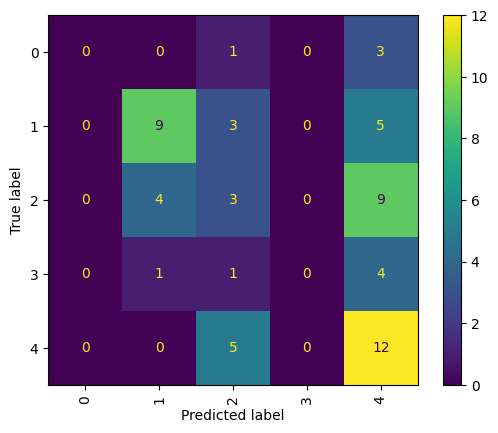

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm)
disp.plot(xticks_rotation=90)
plt.show()

In [ ]:
pd.DataFrame({"knn_accuracy":[acc]}).to_csv(
    f"{RESULTS_DIR}/knn_accuracy.csv", index=False
)

Silhouette score

In [ ]:
sil = silhouette_score(embeddings, y)
print("Silhouette score:", sil)

pd.DataFrame({"silhouette":[sil]}).to_csv(
    f"{RESULTS_DIR}/silhouette_score.csv", index=False
)

Silhouette score: -0.03424141


Intra vs Inter class distance

In [ ]:
dist = cdist(embeddings, embeddings)

intra = []
inter = []

for i in range(len(y)):
    for j in range(len(y)):
        if y[i] == y[j]:
            intra.append(dist[i,j])
        else:
            inter.append(dist[i,j])

intra_mean = np.mean(intra)
inter_mean = np.mean(inter)

print("Intra-class distance:", intra_mean)
print("Inter-class distance:", inter_mean)

df = pd.DataFrame({
    "intra_class_distance":[intra_mean],
    "inter_class_distance":[inter_mean]
})

df.to_csv(f"{RESULTS_DIR}/distance_metrics.csv", index=False)

Intra-class distance: 0.9578180871894233
Inter-class distance: 0.9725330192283076


In [ ]:
from sklearn.metrics import balanced_accuracy_score

balanced_acc = balanced_accuracy_score(y_test, y_pred)
print("Balanced accuracy:", balanced_acc)

Balanced accuracy: 0.28455882352941175


Logistic Regression

In [ ]:
embeddings = np.load("data/processed/ssl_embeddings.npy")
metadata = pd.read_csv("data/processed/metadata_with_moa.csv")

In [ ]:
len(metadata)

300

Standarising

In [ ]:
from sklearn.preprocessing import normalize
embeddings = normalize(embeddings)
X_train, X_test, y_train, y_test = train_test_split(
    embeddings, y, test_size=0.3, random_state=42
)

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score

logreg = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs"
)

logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
bal_acc_lr = balanced_accuracy_score(y_test, y_pred_lr)

print("Logistic Regression Accuracy:", acc_lr)
print("Logistic Regression Balanced Accuracy:", bal_acc_lr)

Logistic Regression Accuracy: 0.3111111111111111
Logistic Regression Balanced Accuracy: 0.21935531135531136


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Visualization:

PCA: messy

UMAP: clusters by MOA (if SSL works)

Compound: subclusters inside MOA

Metrics:

kNN accuracy > random baseline

silhouette > 0.1 is already meaningful for bio data